# matplotlib for Machine Learning
### A junior ML engineer's path to confidence with matplotlib

matplotlib is the layer where an array or a table becomes a picture: a loss curve, a feature histogram, a labeled scatter, a confusion matrix. NumPy gave you fast arrays, pandas gave you clean tables; matplotlib is how you actually look at either one.

## Table of contents
0. [Introduction](#0.-Introduction)
1. [Your first plot: the quick way](#1.-Your-first-plot:-the-quick-way)
2. [The Figure/Axes object model](#2.-The-Figure/Axes-object-model)
3. [Anatomy of a figure](#3.-Anatomy-of-a-figure)
4. [Line and scatter plots](#4.-Line-and-scatter-plots)
5. [Bar charts and histograms](#5.-Bar-charts-and-histograms)
6. [Styling: color, markers, linestyles, and colormaps](#6.-Styling:-color,-markers,-linestyles,-and-colormaps)
7. [Multiple Axes: subplot grids](#7.-Multiple-Axes:-subplot-grids)
8. [Saving and displaying figures](#8.-Saving-and-displaying-figures)
9. [matplotlib in the ML stack](#9.-matplotlib-in-the-ML-stack)
10. [Summary](#10.-Summary)
11. [Exercises](#11.-Exercises)

## 0. Introduction

**matplotlib** is the library the entire Python ML stack draws with. Before a model is trained, you look at your data (a histogram, a scatter of two features). While it trains, you watch the loss curve. After it trains, you read a confusion matrix or an ROC curve. All of that is matplotlib, whether you call it directly or through a wrapper like `pandas.DataFrame.plot()` or seaborn.

**Convention:** import the `pyplot` module as `plt`. That single import is almost everything you need.

In [6]:
import matplotlib.pyplot as plt

print("matplotlib version:", plt.matplotlib.__version__)

ModuleNotFoundError: No module named 'matplotlib'

### 0.1 A quick taste: the same job, two ways

Say you have a small set of category counts and want to see them as a bar chart. In plain Python, "drawing" a bar chart means printing one row of characters per category and hoping the lengths line up:

In [3]:
labels = ["setosa", "versicolor", "virginica"]
counts = [12, 18, 15]

for label, count in zip(labels, counts):
    print(f"{label:>10} | {'#' * count}")

    setosa | ############
versicolor | ##################
 virginica | ###############


It gets the idea across, but there is no real axis, no numeric scale, no way to save it, and no way to combine it with another chart. matplotlib draws the same counts as an actual chart, with a real axis and real proportions, in one call:

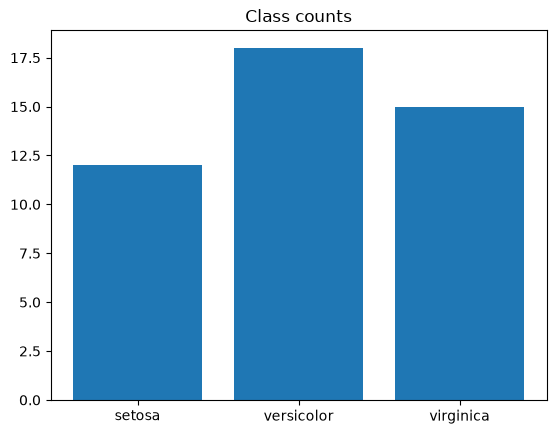

In [4]:
fig, ax = plt.subplots()
ax.bar(labels, counts)
ax.set_title("Class counts")
plt.show()

### 0.2 A first taste of the payoff: capability, not speed

matplotlib does not exist to be fast; it exists so you never have to hand-roll a chart again. The payoff is how much a few `ax` calls can do at once. Here is a two-second preview of what six lines buys you: a line and a histogram, side by side, one figure.

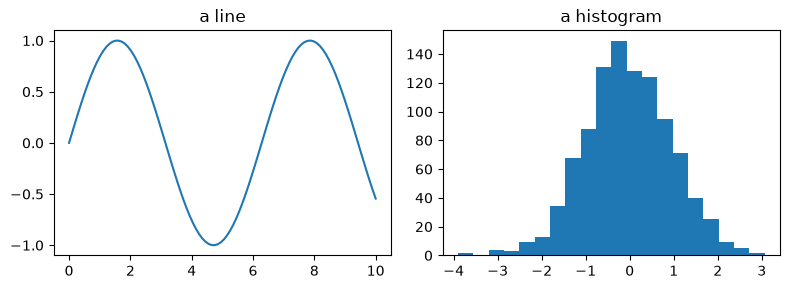

In [5]:
import numpy as np

x = np.linspace(0, 10, 100)
rng = np.random.default_rng(0)

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].plot(x, np.sin(x))
axes[0].set_title("a line")
axes[1].hist(rng.normal(size=1000), bins=20)
axes[1].set_title("a histogram")
fig.tight_layout()
plt.show()

That is the shape of the whole session: build up from one plot to a full grid of them, all through the same handful of `ax` calls. Let's build the mental model that gets us there.

## 1. Your first plot: the quick way

The fastest way to get a plot on screen is `pyplot`'s own top-level functions: `plt.plot`, `plt.title`, and so on. Every one of these quietly edits "whatever figure and axes happen to be current." That is genuinely convenient for a single, throwaway plot, so we start here, on purpose, before Chapter 2 shows why it stops scaling.

### 1.1 A single plot, the pyplot way

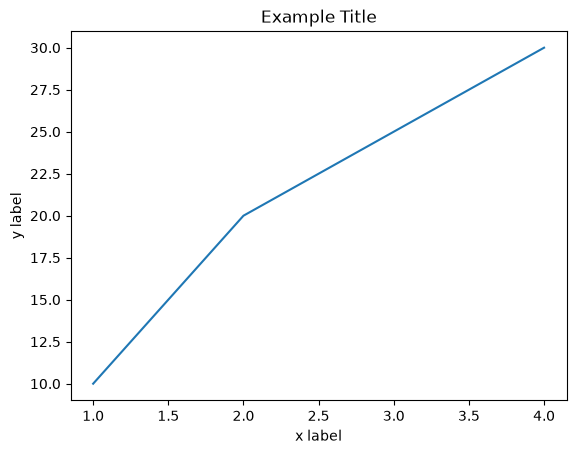

In [6]:
plt.plot([1, 2, 3, 4], [10, 20, 25, 30])
plt.title("Example Title")
plt.xlabel("x label")
plt.ylabel("y label")
plt.show()

### 1.2 The gotcha: two plots, addressed only by "whichever is current"

Now say you want two panels side by side. With bare `pyplot`, you switch which axes is "current" with `plt.subplot(...)`, then every following call edits that one, until the next switch. It works, but nothing in the code says which panel `plt.title(...)` belongs to; you have to track it in your head.

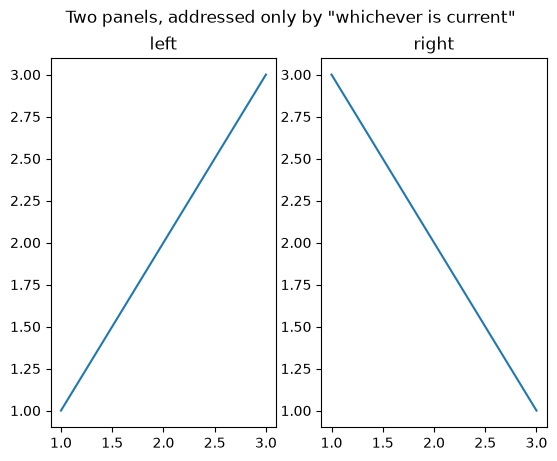

In [7]:
plt.subplot(1, 2, 1)
plt.plot([1, 2, 3], [1, 2, 3])
plt.title("left")

plt.subplot(1, 2, 2)
plt.plot([1, 2, 3], [3, 2, 1])
plt.title("right")

plt.suptitle("Two panels, addressed only by \"whichever is current\"")
plt.show()

> **ML tie-in:** this is the style of plot you write in a throwaway notebook cell to eyeball one array. Fine for that; risky the moment you want more than one panel or a plotting function you can call more than once.

## 2. The Figure/Axes object model

Instead of editing "whatever is current," you can ask for the **Figure** (the whole window or page) and one or more **Axes** (an individual plot inside it) explicitly, and call every method directly on the object you mean. This is the object model the rest of the session builds on.

### 2.1 Rebuilding Chapter 1's single plot, explicitly

`fig, ax = plt.subplots()` hands back both objects at once. Everything that was `plt.something(...)` becomes `ax.set_something(...)`, called on the one object you actually have in hand.

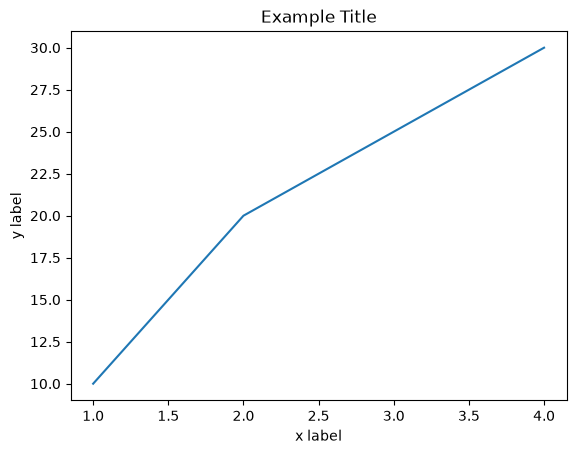

In [8]:
fig, ax = plt.subplots()
ax.plot([1, 2, 3, 4], [10, 20, 25, 30])
ax.set_title("Example Title")
ax.set_xlabel("x label")
ax.set_ylabel("y label")
plt.show()

### 2.2 Rebuilding the two-panel gotcha, explicitly

`plt.subplots(1, 2)` returns an **array of Axes**. Each panel is `axes[0]` or `axes[1]`, a real object you index into, so there is no "current axes" to lose track of.

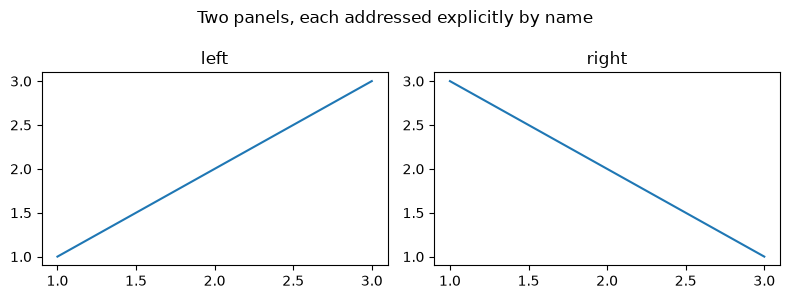

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].plot([1, 2, 3], [1, 2, 3])
axes[0].set_title("left")
axes[1].plot([1, 2, 3], [3, 2, 1])
axes[1].set_title("right")
fig.suptitle("Two panels, each addressed explicitly by name")
fig.tight_layout()
plt.show()

> **ML tie-in:** any plotting code you intend to reuse (a helper called once per epoch, or once per feature) needs a real `ax` object to take as an argument. From here on, every call in this notebook is written on `ax`, never on bare `plt`.

## 3. Anatomy of a figure

A **Figure** is the whole canvas; it can hold one or more **Axes**. Each Axes has its own title, x/y labels, ticks, gridlines, and legend. Keep this picture in mind; every chapter from here on is just "more things you can set on `ax`."

![Figure/Axes anatomy: title, labels, legend, ticks, and grid, all owned by one Axes inside one Figure](assets/matplotlib/diagram_anatomy.png)

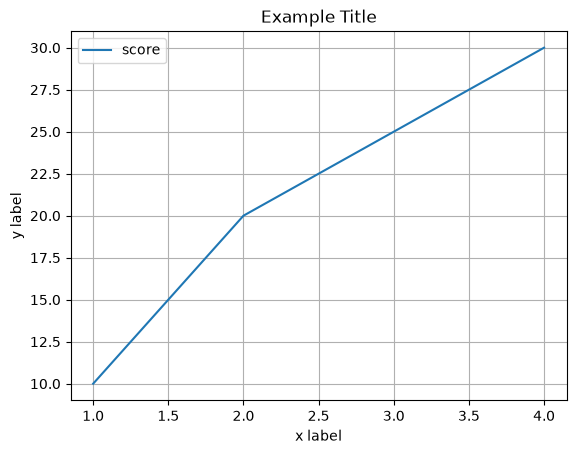

In [10]:
fig, ax = plt.subplots()
ax.plot([1, 2, 3, 4], [10, 20, 25, 30], label="score")
ax.set_title("Example Title")
ax.set_xlabel("x label")
ax.set_ylabel("y label")
ax.legend()
ax.grid(True)
plt.show()

### 3.1 Hand-rolling ticks vs the axes API

You can also set the tick positions and labels yourself with `ax.set_xticks` / `ax.set_xticklabels`, but matplotlib already chose sensible ones above without being asked. Doing it by hand is mostly useful when you want labels that aren't plain numbers.

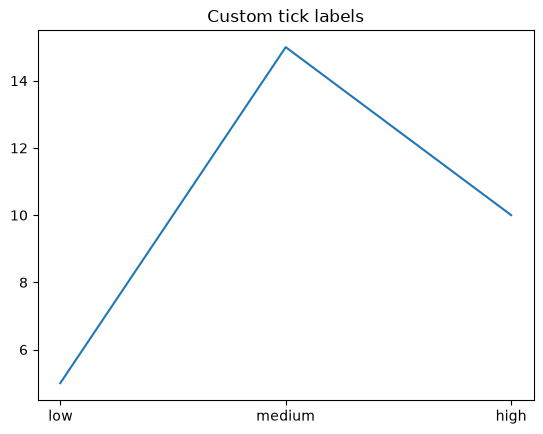

In [11]:
fig, ax = plt.subplots()
ax.plot([0, 1, 2], [5, 15, 10])
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(["low", "medium", "high"])
ax.set_title("Custom tick labels")
plt.show()

> **ML tie-in:** a mislabeled axis or a missing legend is a common way to draw the wrong conclusion from an otherwise correct plot. This chapter is what prevents that.

## 4. Line and scatter plots

Two plot types cover most day-to-day ML plotting: a **line** for a value that changes over an ordered axis (training epoch, time step), and a **scatter** for the relationship between two numeric quantities.

### 4.1 Line plots: a training curve

The single most common plot in ML work is a loss curve: one value per epoch. `ax.plot` draws it directly from an array of per-epoch values.

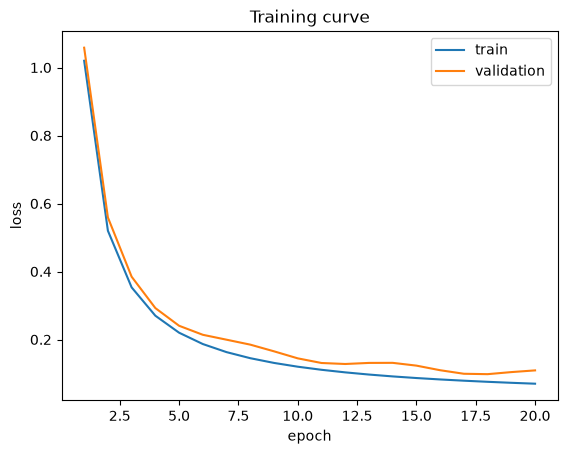

In [12]:
import numpy as np

epochs = np.arange(1, 21)
train_loss = 1.0 / epochs + 0.02
val_loss = 1.0 / epochs + 0.05 + 0.01 * np.sin(epochs)

fig, ax = plt.subplots()
ax.plot(epochs, train_loss, label="train")
ax.plot(epochs, val_loss, label="validation")
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.set_title("Training curve")
ax.legend()
plt.show()

### 4.2 Scatter plots: two features, colored by class

`ax.scatter` plots one point per sample from two arrays, and `c=` colors each point by a third value, most often a class label. Here are two synthetic clusters.

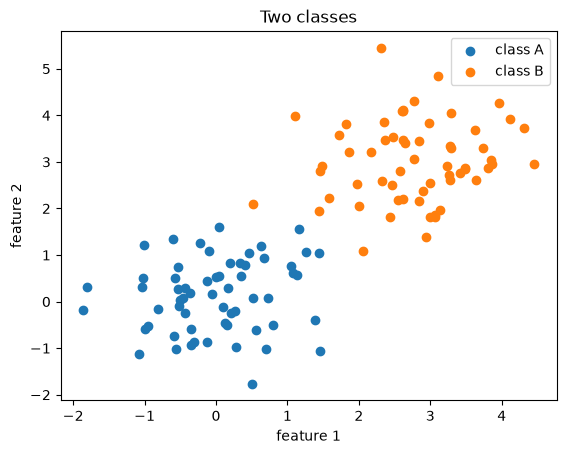

In [13]:
rng = np.random.default_rng(0)
cluster_a = rng.normal(loc=(0, 0), scale=0.8, size=(60, 2))
cluster_b = rng.normal(loc=(3, 3), scale=0.8, size=(60, 2))

fig, ax = plt.subplots()
ax.scatter(cluster_a[:, 0], cluster_a[:, 1], label="class A")
ax.scatter(cluster_b[:, 0], cluster_b[:, 1], label="class B")
ax.set_xlabel("feature 1")
ax.set_ylabel("feature 2")
ax.set_title("Two classes")
ax.legend()
plt.show()

> **ML tie-in:** the loss curve is the plot you will make more than any other during training. A labeled, colored scatter is the standard first look at a new dataset, well before any model is fit.

## 5. Bar charts and histograms

A **bar chart** counts categories; a **histogram** shows the distribution of one numeric feature. Both are the first things you check before modeling.

### 5.1 Bar charts: class balance

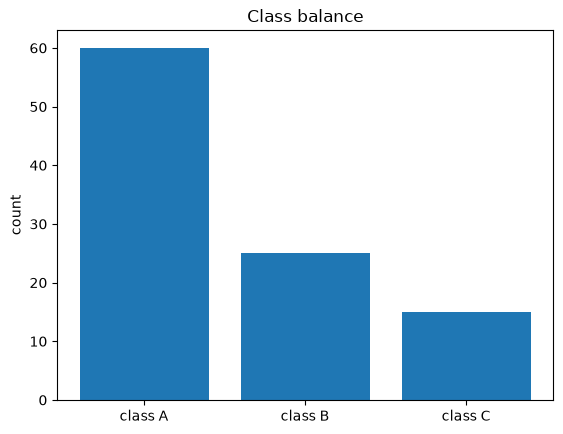

In [14]:
labels = ["class A", "class B", "class C"]
counts = [60, 25, 15]

fig, ax = plt.subplots()
ax.bar(labels, counts)
ax.set_ylabel("count")
ax.set_title("Class balance")
plt.show()

### 5.2 Histograms: one feature's distribution

`ax.hist` bins a numeric array and draws the counts. `bins=` is the one argument that matters most: too few and you lose shape, too many and you see noise.

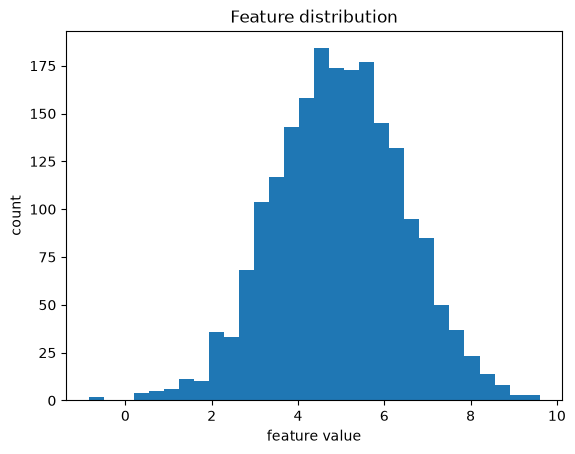

In [15]:
rng = np.random.default_rng(0)
feature = rng.normal(loc=5, scale=1.5, size=2000)

fig, ax = plt.subplots()
ax.hist(feature, bins=30)
ax.set_xlabel("feature value")
ax.set_ylabel("count")
ax.set_title("Feature distribution")
plt.show()

> **ML tie-in:** `value_counts` plus a bar chart is how you check class imbalance before training a classifier. A histogram of a feature is how you decide whether it needs a log transform or a scaler before it goes into a model.

## 6. Styling: color, markers, linestyles, and colormaps

Style is a handful of keyword arguments on the calls you already know: `color`, `marker`, `linestyle`, `alpha`. A colormap does the same job as `c=` in Chapter 4, but for a continuous value instead of a fixed color per class.

### 6.1 Distinguishing series by linestyle and color

The training-curve pattern from Chapter 4 reads better once train and validation are visually distinct, not just labeled.

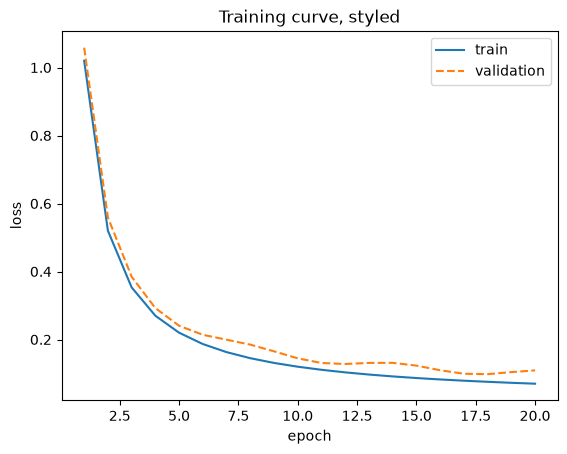

In [16]:
epochs = np.arange(1, 21)
train_loss = 1.0 / epochs + 0.02
val_loss = 1.0 / epochs + 0.05 + 0.01 * np.sin(epochs)

fig, ax = plt.subplots()
ax.plot(epochs, train_loss, color="tab:blue", linestyle="-", label="train")
ax.plot(epochs, val_loss, color="tab:orange", linestyle="--", label="validation")
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.set_title("Training curve, styled")
ax.legend()
plt.show()

### 6.2 Coloring a scatter by a continuous value

`cmap=` maps a numeric array passed to `c=` onto a color gradient, which is how you shade points by a real-valued quantity (a predicted probability, an error size) instead of a fixed class color.

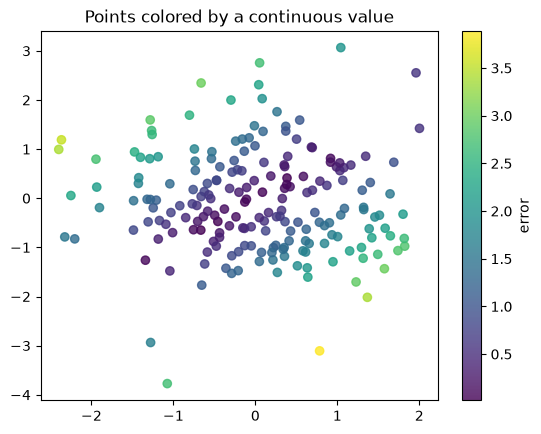

In [17]:
rng = np.random.default_rng(0)
x = rng.normal(size=200)
y = rng.normal(size=200)
error = np.abs(x - y)

fig, ax = plt.subplots()
sc = ax.scatter(x, y, c=error, cmap="viridis", alpha=0.8)
fig.colorbar(sc, ax=ax, label="error")
ax.set_title("Points colored by a continuous value")
plt.show()

> **ML tie-in:** distinguishing train vs validation curves by linestyle keeps a busy plot readable; coloring points by predicted-vs-true error is the fastest way to spot where a model is going wrong.

## 7. Multiple Axes: subplot grids

This is the direct payoff of Chapter 2: once you have an array of `ax` objects, looping over it to fill a grid of panels is routine. Trying the same thing with bare `pyplot` and "whichever is current" would not scale past two panels.

### 7.1 A grid of feature histograms

Given a small matrix of four synthetic features, plot one histogram per feature in a 2x2 grid by looping over the flattened Axes array.

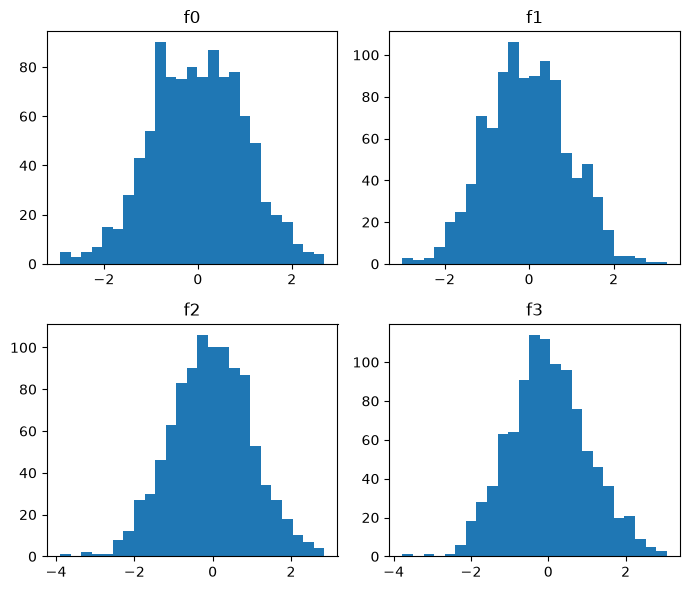

In [18]:
rng = np.random.default_rng(0)
features = rng.normal(size=(1000, 4))
feature_names = ["f0", "f1", "f2", "f3"]

fig, axes = plt.subplots(2, 2, figsize=(7, 6))
for i, ax in enumerate(axes.flat):
    ax.hist(features[:, i], bins=25)
    ax.set_title(feature_names[i])
fig.tight_layout()
plt.show()

> **ML tie-in:** a grid of one histogram per feature, or one predicted-vs-actual scatter per model, is the standard way to compare several things side by side instead of scrolling through separate plots.

## 8. Saving and displaying figures

A notebook shows a figure inline automatically. A report, a slide deck, or a model card needs a file. `fig.savefig(...)` writes one, at a chosen resolution.

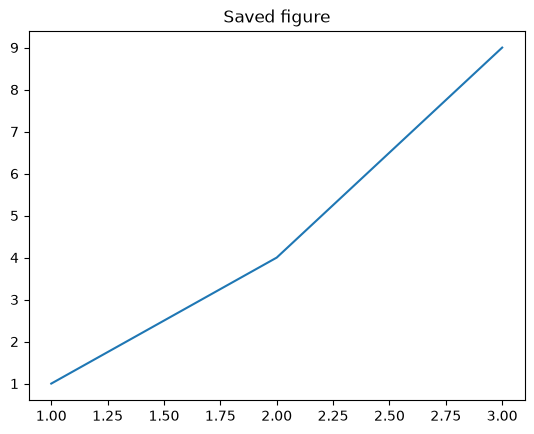

saved to: /tmp/example_figure.png
file exists: True


In [19]:
import tempfile
import os

fig, ax = plt.subplots()
ax.plot([1, 2, 3], [1, 4, 9])
ax.set_title("Saved figure")

out_path = os.path.join(tempfile.gettempdir(), "example_figure.png")
fig.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()

print("saved to:", out_path)
print("file exists:", os.path.exists(out_path))

> **ML tie-in:** saving a figure reproducibly, at a fixed resolution, is how a chart ends up in a report or a model card instead of only ever existing inside a notebook cell.

## 9. matplotlib in the ML stack

matplotlib is the last stop before a human looks at the result. This chapter is the bridge: pandas plotting, images, and a preview of a decision boundary, using the same Iris dataset from the pandas session.

### 9.1 `DataFrame.plot()`: a thin wrapper that still returns an `ax`

pandas' own `.plot()` is matplotlib underneath, and it hands back a real `ax` you can keep customizing with everything from this session.

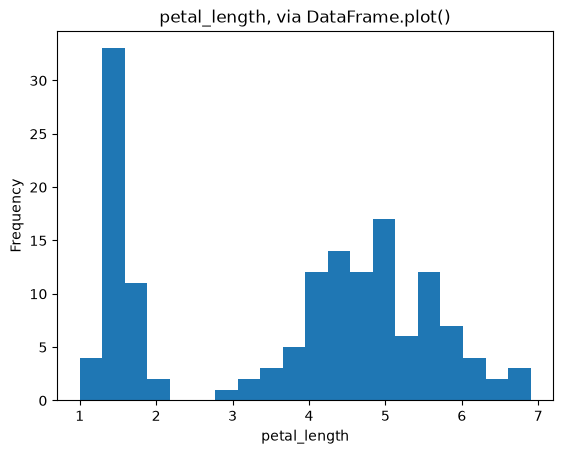

In [20]:
from sklearn.datasets import load_iris
import pandas as pd

bunch = load_iris(as_frame=True)
iris = bunch.frame.rename(columns={
    "sepal length (cm)": "sepal_length",
    "sepal width (cm)":  "sepal_width",
    "petal length (cm)": "petal_length",
    "petal width (cm)":  "petal_width",
})
iris["species"] = iris["target"].map({0: "setosa", 1: "versicolor", 2: "virginica"})
iris = iris.drop(columns="target")

ax = iris["petal_length"].plot(kind="hist", bins=20)
ax.set_xlabel("petal_length")
ax.set_title("petal_length, via DataFrame.plot()")
plt.show()

### 9.2 `ax.imshow()`: a 2-D array as an image

`imshow` renders any 2-D array as a grid of colored cells, which is exactly what a confusion matrix is: rows are true labels, columns are predicted labels, and each cell is a count.

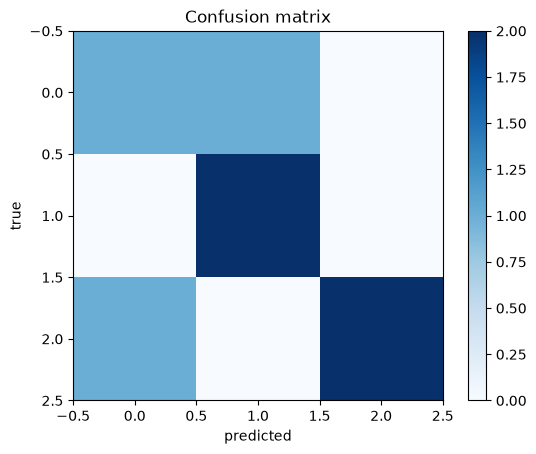

In [21]:
from sklearn.metrics import confusion_matrix

y_true = [0, 0, 1, 1, 2, 2, 2]
y_pred = [0, 1, 1, 1, 2, 2, 0]
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots()
im = ax.imshow(cm, cmap="Blues")
ax.set_xlabel("predicted")
ax.set_ylabel("true")
ax.set_title("Confusion matrix")
fig.colorbar(im, ax=ax)
plt.show()

### 9.3 A decision boundary preview

`np.meshgrid` builds a grid of points covering the plot area (the same broadcasting idea from the NumPy session); a fitted classifier predicts a class for every grid point, and `ax.contourf` colors the plot by that prediction. This is a preview of the pattern, not a lesson in the classifier itself, scikit-learn gets its own sessions later.

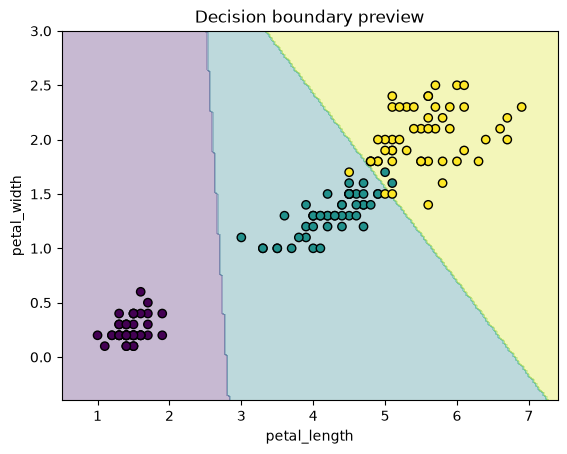

In [22]:
from sklearn.linear_model import LogisticRegression

X2 = iris[["petal_length", "petal_width"]].to_numpy()
y2 = iris["species"].astype("category").cat.codes.to_numpy()

clf = LogisticRegression(max_iter=1000).fit(X2, y2)

xx, yy = np.meshgrid(
    np.linspace(X2[:, 0].min() - 0.5, X2[:, 0].max() + 0.5, 200),
    np.linspace(X2[:, 1].min() - 0.5, X2[:, 1].max() + 0.5, 200),
)
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, ax = plt.subplots()
ax.contourf(xx, yy, Z, alpha=0.3, cmap="viridis")
ax.scatter(X2[:, 0], X2[:, 1], c=y2, cmap="viridis", edgecolor="k")
ax.set_xlabel("petal_length")
ax.set_ylabel("petal_width")
ax.set_title("Decision boundary preview")
plt.show()

### 9.4 The end-to-end payoff

Using only tools from this session: a labeled, legended scatter of two features by species, next to a class-balance bar chart.

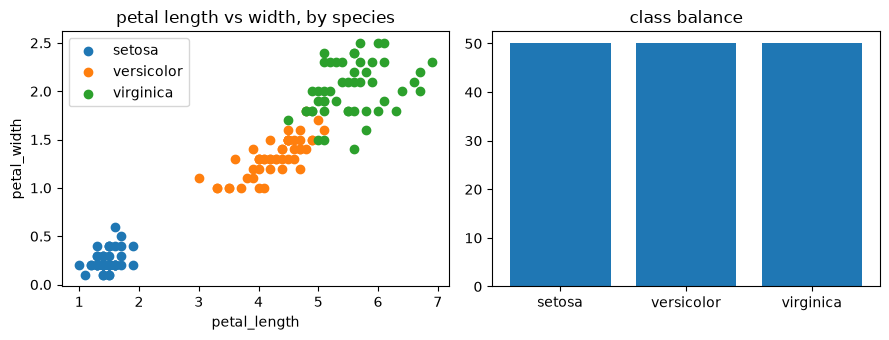

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))

for name, group in iris.groupby("species"):
    axes[0].scatter(group["petal_length"], group["petal_width"], label=name)
axes[0].set_xlabel("petal_length")
axes[0].set_ylabel("petal_width")
axes[0].set_title("petal length vs width, by species")
axes[0].legend()

counts = iris["species"].value_counts()
axes[1].bar(counts.index, counts.values)
axes[1].set_title("class balance")

fig.tight_layout()
plt.show()

> **ML tie-in:** this is the seam between three libraries. pandas cleans and selects, NumPy powers the grid math behind a decision boundary, and matplotlib is what turns all of it into something you can actually read.

## 10. Summary

### Cheat sheet

| Task | Tool |
|---|---|
| Create a figure and axes | `fig, ax = plt.subplots()`; a grid: `plt.subplots(nrows, ncols)` |
| Title and labels | `ax.set_title(...)`, `ax.set_xlabel(...)`, `ax.set_ylabel(...)` |
| Legend and grid | `ax.legend()` (with `label=` on each plot call), `ax.grid(True)` |
| Ticks | `ax.set_xticks(...)`, `ax.set_xticklabels(...)` |
| Line plot | `ax.plot(x, y)` |
| Scatter plot | `ax.scatter(x, y, c=..., cmap=...)` |
| Bar chart | `ax.bar(labels, counts)` |
| Histogram | `ax.hist(values, bins=...)` |
| Style | `color=`, `marker=`, `linestyle=`, `alpha=` |
| Subplot grid | `fig, axes = plt.subplots(nrows, ncols)`; index or loop over `axes` |
| Layout | `fig.tight_layout()` |
| Save | `fig.savefig("name.png", dpi=..., bbox_inches="tight")` |
| Image / confusion matrix | `ax.imshow(array_2d, cmap=...)` |
| From pandas | `df["col"].plot(kind=...)` returns a real `ax` |

## 11. Exercises

Use only what this notebook covered.

1. Given `epoch_losses = [0.9, 0.6, 0.45, 0.38, 0.34, 0.31, 0.30]`, plot it as a labeled line chart with a title, x label "epoch", and y label "loss".
2. Given `labels = ["cat", "dog", "cat", "cat", "bird", "dog"]`, use `np.unique` with `return_counts=True` to get the category counts, then draw them as a bar chart.
3. Given `data = rng.normal(size=(2000, 4))` (four synthetic features), build a 2x2 grid of histograms, one per feature, looping over the flattened Axes array. No manual copy-pasted subplot calls.
4. Given `y_true` and `y_pred` arrays of 0/1 labels, build a scatter of two feature arrays `x1`, `x2` where each point is colored by whether the prediction was correct (`y_true == y_pred`), with a legend for "correct" and "incorrect".
5. Build any labeled figure, save it with `fig.savefig(...)` at `dpi=200`, and confirm with `os.path.exists(...)` that the file was written.